# South Korea's Growth and Development analysis

In [1]:

!pip install statsmodels
!pip install numpy
!pip install pandas

In [2]:
!pip install matplotlib
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install openpyxl

In [96]:
data = pd.read_excel(r'C:\Users\dell\OneDrive\Documents\SSE\GD\pwt110.xlsx', sheet_name= 'Sheet2')

In [97]:
data.info()
data['year'] = pd.to_datetime(data['year'], format='%Y')

<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           67 non-null     float64
 1   rgdpe          67 non-null     float64
 2   rgdpo          67 non-null     float64
 3   cgdpe          67 non-null     float64
 4   cgdpo          67 non-null     float64
 5   cn             67 non-null     float64
 6   rgdpna         67 non-null     float64
 7   rconna         67 non-null     float64
 8   rdana          67 non-null     float64
 9   rnna           67 non-null     float64
 10  pop            67 non-null     float64
 11  emp            67 non-null     float64
 12  irr            67 non-null     float64
 13  delta          67 non-null     float64
 14  rtfpna         67 non-null     float64
 15  export         65 non-null     float64
 16  trade          65 non-null     object 
 17  high_exports   18 non-null     float64
 18  gfcf           65 non-n

In [98]:
data.index = pd.PeriodIndex(data['year'], freq='Y')
data.drop(columns=['year'], inplace=True)


In [99]:
data.sort_index(inplace=True)
data['RIR'] = data['RIR'].astype(float)

In [100]:
data

,rgdpe,rgdpo,cgdpe,cgdpo,cn,rgdpna,rconna,rdana,rnna,pop,...,irr,delta,rtfpna,export,trade,high_exports,gfcf,RIR,con_expe,final_con_PIP
year,,,,,,,,,,,,,,,,,,,,,
1957,3.268756e+04,3.295155e+04,3.436359e+04,3.403884e+04,2.155726e+05,4.461884e+04,4.909672e+04,5.052773e+04,1.830345e+05,22.822789,...,0.114209,0.027590,0.391713,2.631579,14.553429,NaN,11.204147,NaN,NaN,NaN
1958,3.369983e+04,3.415745e+04,3.551961e+04,3.560029e+04,2.162890e+05,4.617504e+04,5.082209e+04,5.110946e+04,1.833366e+05,23.470858,...,0.121510,0.027489,0.404374,4.027732,,NaN,11.687025,NaN,NaN,NaN
1959,3.408021e+04,3.486209e+04,3.585266e+04,3.632298e+04,2.139041e+05,4.699340e+04,5.288839e+04,5.106291e+04,1.819736e+05,24.205347,...,0.109424,0.027258,0.414188,3.863946,19.401361,NaN,13.768707,NaN,NaN,NaN
1960,3.409043e+04,3.521473e+04,3.605902e+04,3.654425e+04,2.112903e+05,4.754741e+04,5.356448e+04,5.198218e+04,1.810267e+05,25.015673,...,0.119657,0.026968,0.420574,3.934741,18.522073,NaN,13.474088,NaN,3.575486e+10,NaN
1961,3.580989e+04,3.772867e+04,3.788565e+04,3.924679e+04,2.098901e+05,4.969170e+04,5.522455e+04,5.491948e+04,1.816221e+05,25.853127,...,0.137279,0.026826,0.424027,4.936113,17.256221,NaN,11.513114,NaN,3.654344e+10,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,2.588778e+06,2.665120e+06,2.571554e+06,2.652868e+06,1.376681e+07,2.672703e+06,1.564094e+06,2.495382e+06,1.351781e+07,51.858482,...,0.073534,0.052152,0.987357,41.321481,82.258009,30.276280,31.447015,1.195502,1.099655e+12,1.050011e+12
2021,2.691083e+06,2.795994e+06,2.691083e+06,2.795994e+06,1.398631e+07,2.795994e+06,1.630350e+06,2.600358e+06,1.398631e+07,51.848397,...,0.075814,0.052439,1.000000,44.358238,84.642495,36.258256,30.029371,-0.287216,1.146239e+12,1.089266e+12
2022,2.669096e+06,2.869279e+06,2.686164e+06,2.887701e+06,1.449746e+07,2.872256e+06,1.698371e+06,2.672612e+06,1.443600e+07,51.782512,...,0.068568,0.052841,0.997360,NaN,NaN,NaN,NaN,2.440529,1.194056e+12,1.135200e+12


In [72]:
data.info()

<class 'pandas.DataFrame'>
PeriodIndex: 68 entries, 1957 to NaT
Freq: Y-DEC
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rgdpe         67 non-null     float64
 1   rgdpo         67 non-null     float64
 2   cgdpe         67 non-null     float64
 3   cgdpo         67 non-null     float64
 4   cn            67 non-null     float64
 5   rgdpna        67 non-null     float64
 6   rconna        67 non-null     float64
 7   rdana         67 non-null     float64
 8   rnna          67 non-null     float64
 9   pop           67 non-null     float64
 10  emp           67 non-null     float64
 11  irr           67 non-null     float64
 12  delta         67 non-null     float64
 13  rtfpna        67 non-null     float64
 14  export        65 non-null     float64
 15  trade         65 non-null     object 
 16  high_exports  18 non-null     float64
 17  gfcf          65 non-null     float64
 18  RIR           29 non-null 

In [101]:
print(data.columns, data.size, data.shape, data.ndim)

Index(['rgdpe', 'rgdpo', 'cgdpe', 'cgdpo', 'cn', 'rgdpna', 'rconna', 'rdana',
       'rnna', 'pop', 'emp', 'irr', 'delta', 'rtfpna', 'export', 'trade',
       'high_exports', 'gfcf', 'RIR', 'con_expe', 'final_con_PIP'],
      dtype='str') 1428 (68, 21) 2


### create log and lag variables 
### growth rate (g)

In [10]:
#data['ln_gdp'] = np.log(data['real_gdp'])
#data['ln_capital'] = np.log(data['capital_stock'])
#data['ln_labour'] = np.log(data['labour_force'])
#data['ln_investment'] = np.log(data['investment'])
#data['ln_consumption'] = np.log(data['consumption'])

# lag 
#data['ln_gdp_t-1'] = data['ln_gdp'].shift(1)
#data['ln_labour_t-1'] = data['ln_labour'].shift(1)
#data['ln_investment_t-1'] = data['ln_investment'].shift(1)
#data['ln_consumption_t-1'] = data['ln_consumption'].shift(1)
#data['ln_investment_t-2'] = data['ln_investment'].shift(2)
#data['ln_consumption_t-2'] = data['ln_consumption'].shift(2)
#data['HCI_t-1'] = data['human_capital_index'].shift(1)
#data['real_gdp_t-1']= data['real_gdp'].shift(1)

# growth_rate 

#data['growth_rate'] = (data['ln_gdp']- data['ln_gdp_t-1'])

compute alpha and beta for production function

In [ ]:
# regression 
#pro_x = data[['ln_capital','ln_labour']]
# add intercept
#pro_x = sm.add_constant(pro_x)
#pro_y = data['ln_gdp']

#pro_model = sm.OLS(pro_y, pro_x, missing='drop').fit()
#print(pro_model.summary())
#alpha = pro_model.params['ln_capital']
#beta = pro_model.params['ln_labour']
#A = np.exp(pro_model.params['const'])

#print(f"Calculated Alpha (Capital Elasticity): {alpha:.4f}")
#print(f"Calculated Beta (Labor Elasticity): {beta:.4f}")
#print(f"Total Factor Productivity (A): {A:.4f}")


                            OLS Regression Results                            
Dep. Variable:                 ln_gdp   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 1.137e+04
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           5.77e-76
Time:                        15:54:52   Log-Likelihood:                 74.772
No. Observations:                  61   AIC:                            -143.5
Df Residuals:                      58   BIC:                            -137.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3879      0.166     14.408      0.0

In [ ]:
# define Cobb-Douglas production function

#def cobb_douglus_fn(A=1.0,alpha = 0.2446):
   # return A * (data['capital_stock'] ** alpha ) * (data['labour_force'] **(1 - alpha))

#predicted_Y = cobb_douglus_fn()
#print (predicted_Y)
    

year
1959     83.279930
1960     84.515062
1961     86.953184
1962     89.792709
1963     92.913041
           ...    
2015    591.793097
2016    599.915184
2017    613.344261
2018    618.819446
2019    627.398380
Freq: Y-DEC, Length: 61, dtype: float64


## estimating theta



In [106]:
data.columns

Index(['rgdpe', 'rgdpo', 'cgdpe', 'cgdpo', 'cn', 'rgdpna', 'rconna', 'rdana',
       'rnna', 'pop', 'emp', 'irr', 'delta', 'rtfpna', 'export', 'trade',
       'high_exports', 'gfcf', 'RIR', 'con_expe', 'final_con_PIP', 'log_RIR',
       'r', 'log_r', 'c_growth'],
      dtype='str')

c:\Users\dell\OneDrive\Documents\SSE\GD\country-specific\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='year', ylabel='RIR'>

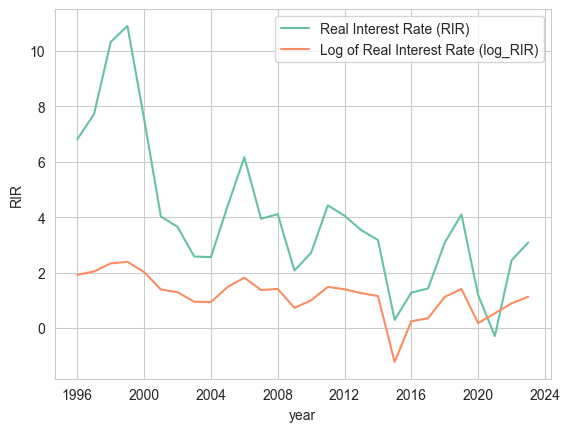

In [102]:

sns.lineplot(x=data.index.to_timestamp(), y=data['RIR'], markers=True, label='Real Interest Rate (RIR)')

data['log_RIR'] = np.log(data['RIR'])
sns.lineplot(x=data.index.to_timestamp(), y=data['log_RIR'], markers=True, label='Log of Real Interest Rate (log_RIR)')

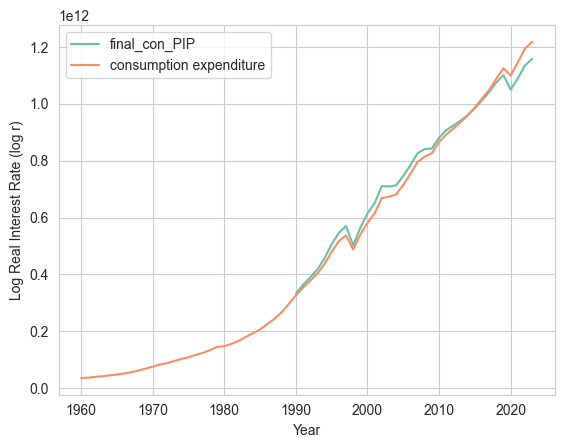

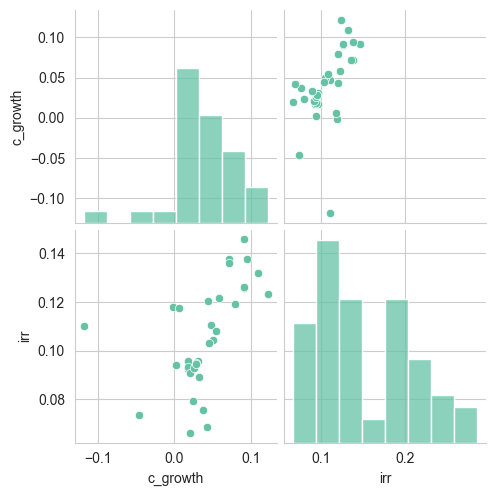

In [ ]:
# R = r - delta

sns.set_style('whitegrid')
sns.lineplot(x=data.index.to_timestamp(), y=data['final_con_PIP'],markers=True,label='final_con_PIP')
sns.lineplot(x=data.index.to_timestamp(), y=data['con_expe'], label='consumption expenditure')
plt.xlabel('Year')
plt.ylabel('Log Real Interest Rate (log r)')

# RIR 
# creating growth rate of consumption
data['c_growth'] = (data['final_con_PIP'] - data['final_con_PIP'].shift(1))/ data['final_con_PIP'].shift(1)

# segma estimation from regression

# correlation
pd.DataFrame({'c_growth': data['c_growth'], 'irr': data['irr']}).corr()
sns.pairplot(data[['c_growth', 'irr']])

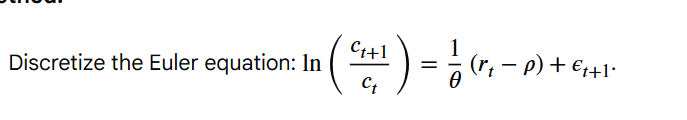

In [116]:
# lag of RIR 

# intertemporal elasticity of substitution (segma) estimation from regression
data['log_pop'] = np.log(data['pop'])

X = data[['log_RIR', 'log_pop']]
y = data['c_growth']
X = sm.add_constant(X)
regmodel = sm.OLS(y, X, missing='drop').fit()
print(regmodel.summary())

                            OLS Regression Results                            
Dep. Variable:               c_growth   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                    0.7401
Date:                Thu, 19 Mar 2026   Prob (F-statistic):              0.488
Time:                        02:30:42   Log-Likelihood:                 46.965
No. Observations:                  27   AIC:                            -87.93
Df Residuals:                      24   BIC:                            -84.04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7243      1.096      0.661      0.5

# ARIMA
Autoregressive Integrated Moving Average model

In [21]:
# random walk
from statsmodels.tsa.arima.model import ARIMA
# Assumes column 'Value' is your time series
ARIMA_model1 = ARIMA(data['ln_gdp'], order=(0,1,0)).fit()
forecast1 = ARIMA_model1.forecast(steps=12)
print(ARIMA_model1.summary())
print(forecast1)

#differenced first-order autoregressive model
ARIMA_model2 = ARIMA(data['ln_gdp'], order=(1,1,0)).fit()
forecast2 = ARIMA_model2.forecast(steps=12)
print(ARIMA_model2.summary())
print(forecast2)

#ARIMA(0,1,1) without constant = simple exponential smoothing
ARIMA_model3 = ARIMA(data['ln_gdp'], order=(0,1,1)).fit()
print(ARIMA_model3.summary())
forecast3 = ARIMA_model3.forecast(steps=12)
print(forecast3)

#ARIMA(1,1,1)
ARIMA_model4 = ARIMA(data['ln_gdp'], order=(1,1,1)).fit()
print(ARIMA_model4.summary())
forecast4 = ARIMA_model4.forecast(steps=12)
print(forecast4)

                               SARIMAX Results                                
Dep. Variable:                 ln_gdp   No. Observations:                   61
Model:                 ARIMA(0, 1, 0)   Log Likelihood                  58.700
Date:                Fri, 13 Mar 2026   AIC                           -115.400
Time:                        15:59:12   BIC                           -113.305
Sample:                    12-31-1959   HQIC                          -114.580
                         - 12-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0083      0.002      3.724      0.000       0.004       0.013
Ljung-Box (L1) (Q):                  16.61   Jarque-Bera (JB):                 2.98
Prob(Q):                              0.00   Pr

## per capita terms

In [ ]:
y = (data['real_gdp']/data['labour_force'])
k = (data['capital_stock']/data['labour_force'])
c = (data['consumption']/data['labour_force'])

# Solow model 

In [ ]:
# growth rates 

n = 